# Análise Exploratória de Dados - Manutenção Prescritiva

## Objetivo

Este notebook conclui a AED do arquivo `data/raw/banner.csv` com foco no que o projeto pede: entender a qualidade dos dados, o comportamento das variáveis de sensores, a estrutura dos rótulos de falha e a prontidão do acervo para um pipeline de manutenção prescritiva orientado por similaridade e documentação técnica.

## Perguntas que a análise responde

1. O dataset está íntegro para uso analítico?
2. Quais famílias de falha dominam a base e como elas se distribuem?
3. Como a rotação (`rpm`) e as variáveis vibracionais afetam a leitura do problema?
4. Há cobertura documental suficiente para sustentar um motor prescritivo?
5. Quais ajustes são necessários antes da modelagem?


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

ROOT = Path.cwd().resolve().parent
DATASET_PATH = ROOT / 'data' / 'raw' / 'banner.csv'
print(f'Raiz do projeto: {ROOT}')
print(f'Dataset: {DATASET_PATH}')


Raiz do projeto: C:\Projetos\Manutencao-prescritiva-main
Dataset: C:\Projetos\Manutencao-prescritiva-main\data\raw\banner.csv


In [2]:
DOCUMENTED_FAMILIES = {
    'rolamento_inner': 'Doc1.pdf - Rolamentos',
    'rolamento_outer': 'Doc1.pdf - Rolamentos',
    'rolamento_ball': 'Doc1.pdf - Rolamentos',
    'rolamento_combination': 'Doc1.pdf - Rolamentos',
    'desalinhamento': 'Doc2.pdf - Desalinhamento',
    'desbalanceamento': 'Doc3.pdf - Desbalanceamento',
    'correia': 'Doc4.pdf - Correias',
    'polia': 'Doc5.pdf - Polias',
    'cocked_rotor': 'Doc6.pdf - Cocked Rotor',
}

def canonical_fault_name(raw_fault: str) -> str:
    value = str(raw_fault).strip().lower()
    value = value.replace('ã', 'a').replace('ç', 'c')
    value = re.sub(r'^new_', '', value)
    
    if 'rolamento_inner' in value:
        return 'rolamento_inner'
    if 'rolamento_outer' in value:
        return 'rolamento_outer'
    if 'rolamento_ball' in value:
        return 'rolamento_ball'
    if 'rolamento_comb' in value:
        return 'rolamento_combination'
    if 'desalinh' in value:
        return 'desalinhamento'
    if any(term in value for term in ['desbalance', 'desabalance', 'desbanlance', 'desabance']):
        return 'desbalanceamento'
    if 'cocked' in value or 'cocke' in value:
        return 'cocked_rotor'
    if 'eccentric' in value:
        return 'eccentric_rotor'
    if 'polia' in value:
        return 'polia'
    if 'correia' in value:
        return 'correia'
    if 'ventoinha' in value:
        return 'ventoinha'
    if 'falta_fase' in value:
        return 'falta_fase'
    if 'motor_desligado' in value or 'mortor_desligado' in value:
        return 'motor_desligado'
    if 'normal' in value or 'baseline' in value:
        return 'normal'
    if 'teste' in value:
        return 'teste'
    if 'acelerando' in value:
        return 'transiente_aceleracao'
    return 'outros'

df = pd.read_csv(DATASET_PATH)
df['created_at'] = pd.to_datetime(df['created_at'], utc=True)
df['canonical_fault'] = df['fault'].map(canonical_fault_name)
df['documented'] = df['canonical_fault'].isin(DOCUMENTED_FAMILIES)
df['date'] = df['created_at'].dt.date
df.head()


,id,created_at,z_rms_velocity_in_s,z_rms_velocity_mm_s,temperature_f,temperature_c,x_rms_velocity_in_s,x_rms_velocity_mm_s,z_peak_acceleration_g,x_peak_acceleration_g,...,z_peak_velocity_mm_s,x_peak_velocity_in_s,x_peak_velocity_mm_s,z_high_freq_rms_accel_g,x_high_freq_rms_accel_g,fault,rpm,canonical_fault,documented,date
0,1426,2026-04-30 17:17:41.549800+00:00,0.0427,1.086,74.00,23.33,0.0619,1.573,0.031,0.033,...,1.536,0.0875,2.224,0.007,0.008,motor_desligado,0.0,motor_desligado,False,2026-04-30
1,1427,2026-04-30 17:17:43.549806+00:00,0.0431,1.095,73.91,23.28,0.0622,1.581,0.039,0.040,...,1.549,0.0880,2.236,0.007,0.008,motor_desligado,0.0,motor_desligado,False,2026-04-30
2,1428,2026-04-30 17:17:45.550674+00:00,0.0431,1.095,74.00,23.33,0.0622,1.581,0.039,0.040,...,1.549,0.0880,2.236,0.007,0.008,motor_desligado,0.0,motor_desligado,False,2026-04-30
3,1429,2026-04-30 17:17:47.551119+00:00,0.0431,1.096,74.00,23.33,0.0617,1.568,0.070,0.100,...,1.550,0.0873,2.218,0.007,0.009,motor_desligado,0.0,motor_desligado,False,2026-04-30
4,1430,2026-04-30 17:17:49.553252+00:00,0.0440,1.119,73.96,23.31,0.0615,1.563,0.031,0.049,...,1.583,0.0870,2.210,0.007,0.008,motor_desligado,0.0,motor_desligado,False,2026-04-30


## 1. Qualidade e integridade dos dados

In [3]:
quality_summary = pd.DataFrame({
    'metrica': [
        'registros', 'colunas', 'faltantes_totais', 'ids_duplicados',
        'classes_originais', 'familias_canonicas', 'rpm_unicos', 'periodo_inicial', 'periodo_final'
    ],
    'valor': [
        len(df),
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df['id'].duplicated().sum()),
        df['fault'].nunique(),
        df['canonical_fault'].nunique(),
        df['rpm'].nunique(),
        df['created_at'].min(),
        df['created_at'].max(),
    ]
})
quality_summary


,metrica,valor
0,registros,166796
1,colunas,29
2,faltantes_totais,0
3,ids_duplicados,0
4,classes_originais,151
5,familias_canonicas,17
6,rpm_unicos,5
7,periodo_inicial,2026-04-30 17:17:41.549800+00:00
8,periodo_final,2026-06-16 18:59:43.447238+00:00


In [4]:
display(df.dtypes.to_frame('dtype').T)
display(df.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(3).head(10))


,id,created_at,z_rms_velocity_in_s,z_rms_velocity_mm_s,temperature_f,temperature_c,x_rms_velocity_in_s,x_rms_velocity_mm_s,z_peak_acceleration_g,x_peak_acceleration_g,...,z_peak_velocity_mm_s,x_peak_velocity_in_s,x_peak_velocity_mm_s,z_high_freq_rms_accel_g,x_high_freq_rms_accel_g,fault,rpm,canonical_fault,documented,date
dtype,int64,"datetime64[us, UTC]",float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,str,float64,str,bool,object


,mean,std,min,25%,50%,75%,max
id,93719.963,50368.322,1426.000,51673.750,93403.500,137442.250,181565.000
z_rms_velocity_in_s,0.068,0.028,0.012,0.057,0.063,0.072,1.460
z_rms_velocity_mm_s,1.728,0.712,0.312,1.443,1.600,1.834,37.095
temperature_f,73.889,4.016,60.130,71.530,74.000,76.910,92.870
temperature_c,23.270,2.231,15.630,21.960,23.330,24.950,33.820
x_rms_velocity_in_s,0.098,0.023,0.017,0.082,0.095,0.109,0.722
x_rms_velocity_mm_s,2.497,0.582,0.438,2.083,2.415,2.774,18.346
z_peak_acceleration_g,0.583,0.786,0.021,0.449,0.500,0.579,38.409
x_peak_acceleration_g,0.722,0.621,0.022,0.524,0.587,0.878,25.241
z_peak_vel_comp_freq_hz,55.763,29.720,9.700,58.500,61.000,61.000,632.300


Leitura inicial: a base está íntegra do ponto de vista estrutural, sem faltantes nem duplicidade de `id`, mas a semântica da coluna `fault` exige padronização antes da modelagem.

## 2. Distribuição dos rótulos e padronização das falhas

In [5]:
top_faults = df['fault'].value_counts().head(20)
top_faults


fault
rolamento_inner            13000
eccentric_rotor            11808
desbalanceado_1parafuso    10079
cocked_rotor               10000
rolamento_outer            10000
rolamento_combination      10000
rolamento_ball              9004
polia                       9000
ventoinha                   9000
correia                     9000
normal_2                    6000
normal                      5738
desalinhado                 4000
desalinhado_2               3998
cocked_rotor_2              3075
rolamento_inner_2           3012
eccentric_rotor_2           3000
polia_2                     3000
rolamento_outer_2           3000
rolamento_ball_2            3000
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_10752\2503829670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_faults.values, y=top_faults.index, palette='viridis')


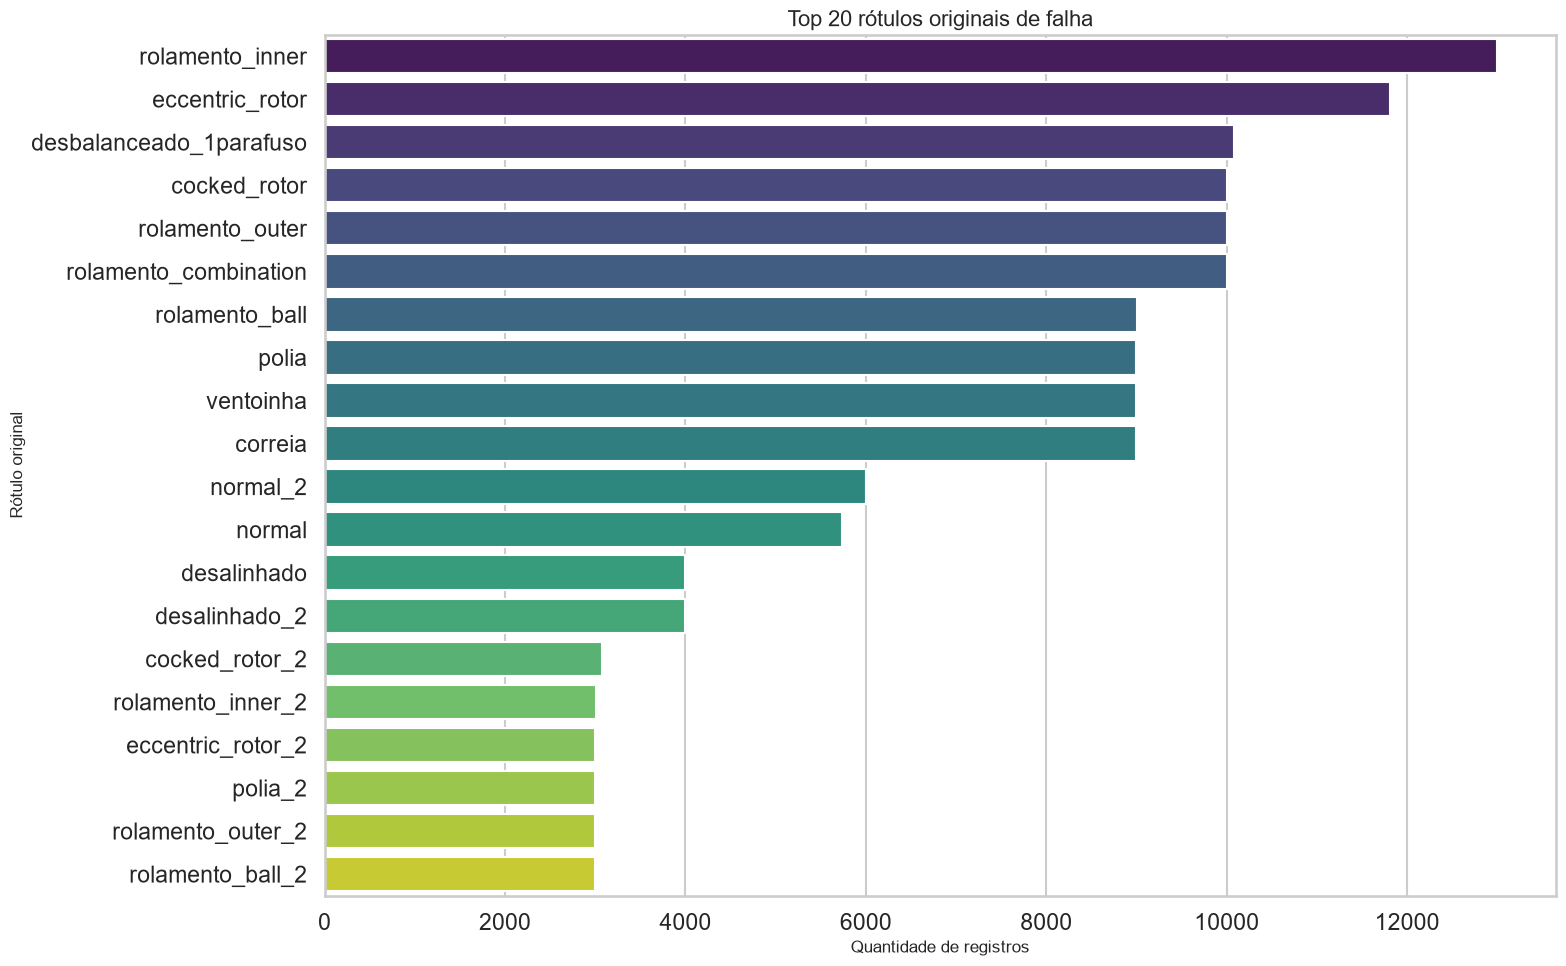

In [6]:
plt.figure(figsize=(16, 10))
sns.barplot(x=top_faults.values, y=top_faults.index, palette='viridis')
plt.title('Top 20 rótulos originais de falha')
plt.xlabel('Quantidade de registros')
plt.ylabel('Rótulo original')
plt.tight_layout()
plt.show()


In [7]:
canonical_counts = (
    df['canonical_fault']
    .value_counts()
    .rename_axis('familia_falha')
    .reset_index(name='quantidade')
)
canonical_counts['percentual'] = (canonical_counts['quantidade'] / len(df) * 100).round(2)
canonical_counts['documentado'] = canonical_counts['familia_falha'].isin(DOCUMENTED_FAMILIES)
canonical_counts


,familia_falha,quantidade,percentual,documentado
0,rolamento_inner,17712,10.62,True
1,eccentric_rotor,16497,9.89,False
2,normal,15077,9.04,False
3,rolamento_outer,14813,8.88,True
4,rolamento_combination,14550,8.72,True
5,cocked_rotor,14275,8.56,True
6,rolamento_ball,13704,8.22,True
7,desbalanceamento,13237,7.94,True
8,ventoinha,12299,7.37,False
9,polia,12000,7.19,True


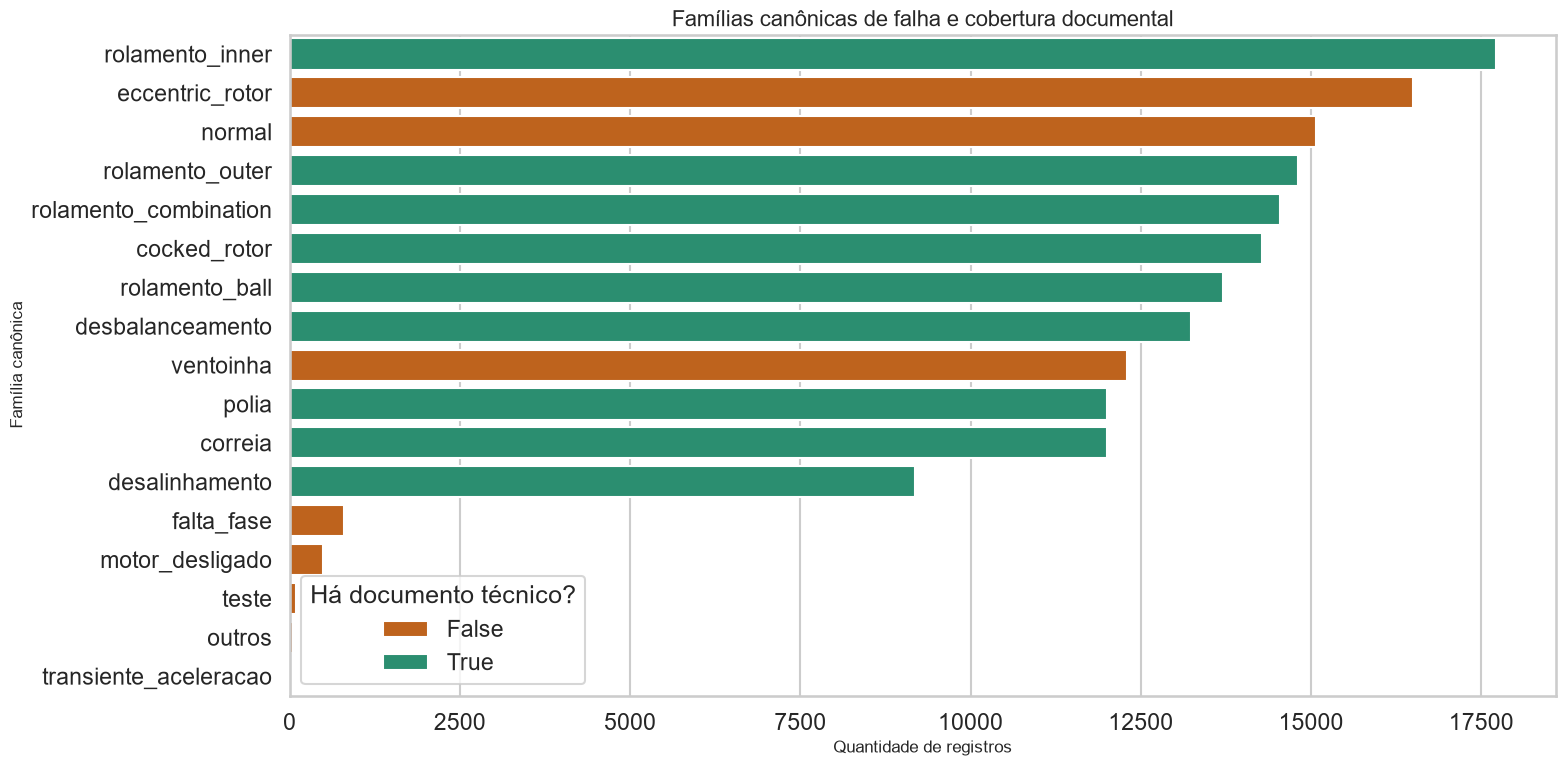

In [8]:
plt.figure(figsize=(16, 8))
order = canonical_counts['familia_falha']
sns.barplot(data=canonical_counts, x='quantidade', y='familia_falha', hue='documentado', dodge=False, palette=['#d95f02', '#1b9e77'], order=order)
plt.title('Famílias canônicas de falha e cobertura documental')
plt.xlabel('Quantidade de registros')
plt.ylabel('Família canônica')
plt.legend(title='Há documento técnico?')
plt.tight_layout()
plt.show()


In [9]:
coverage_summary = canonical_counts.copy()
coverage_summary['documento_referencia'] = coverage_summary['familia_falha'].map(DOCUMENTED_FAMILIES).fillna('Sem documento')
coverage_summary


,familia_falha,quantidade,percentual,documentado,documento_referencia
0,rolamento_inner,17712,10.62,True,Doc1.pdf - Rolamentos
1,eccentric_rotor,16497,9.89,False,Sem documento
2,normal,15077,9.04,False,Sem documento
3,rolamento_outer,14813,8.88,True,Doc1.pdf - Rolamentos
4,rolamento_combination,14550,8.72,True,Doc1.pdf - Rolamentos
5,cocked_rotor,14275,8.56,True,Doc6.pdf - Cocked Rotor
6,rolamento_ball,13704,8.22,True,Doc1.pdf - Rolamentos
7,desbalanceamento,13237,7.94,True,Doc3.pdf - Desbalanceamento
8,ventoinha,12299,7.37,False,Sem documento
9,polia,12000,7.19,True,Doc5.pdf - Polias


A consolidação em famílias canônicas reduz o ruído taxonômico do dataset e mostra com clareza o que já pode alimentar um pipeline prescritivo baseado em documentação.

## 3. Cobertura temporal e regimes de operação

In [10]:
daily_volume = df.groupby('date').size().rename('registros').reset_index()
daily_volume.head()


,date,registros
0,2026-04-30,6046
1,2026-05-04,2864
2,2026-05-06,1803
3,2026-05-07,1000
4,2026-05-12,303


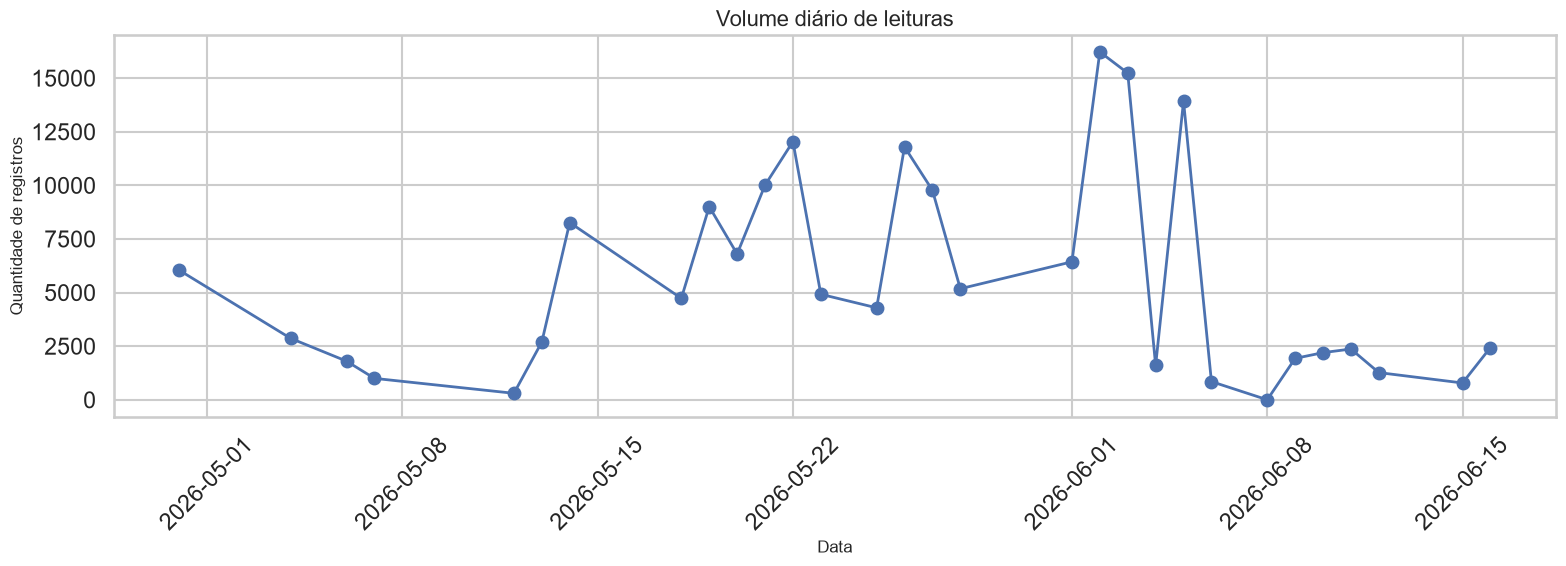

In [11]:
plt.figure(figsize=(16, 6))
plt.plot(pd.to_datetime(daily_volume['date']), daily_volume['registros'], marker='o', linewidth=2)
plt.title('Volume diário de leituras')
plt.xlabel('Data')
plt.ylabel('Quantidade de registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
rpm_distribution = df['rpm'].value_counts().sort_index().rename_axis('rpm').reset_index(name='quantidade')
rpm_distribution['percentual'] = (rpm_distribution['quantidade'] / len(df) * 100).round(2)
rpm_distribution


,rpm,quantidade,percentual
0,0.0,658,0.39
1,500.0,55857,33.49
2,1000.0,53414,32.02
3,2000.0,55160,33.07
4,3000.0,1707,1.02


C:\Users\User\AppData\Local\Temp\ipykernel_10752\1003506052.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rpm_distribution, x='rpm', y='quantidade', palette='mako')


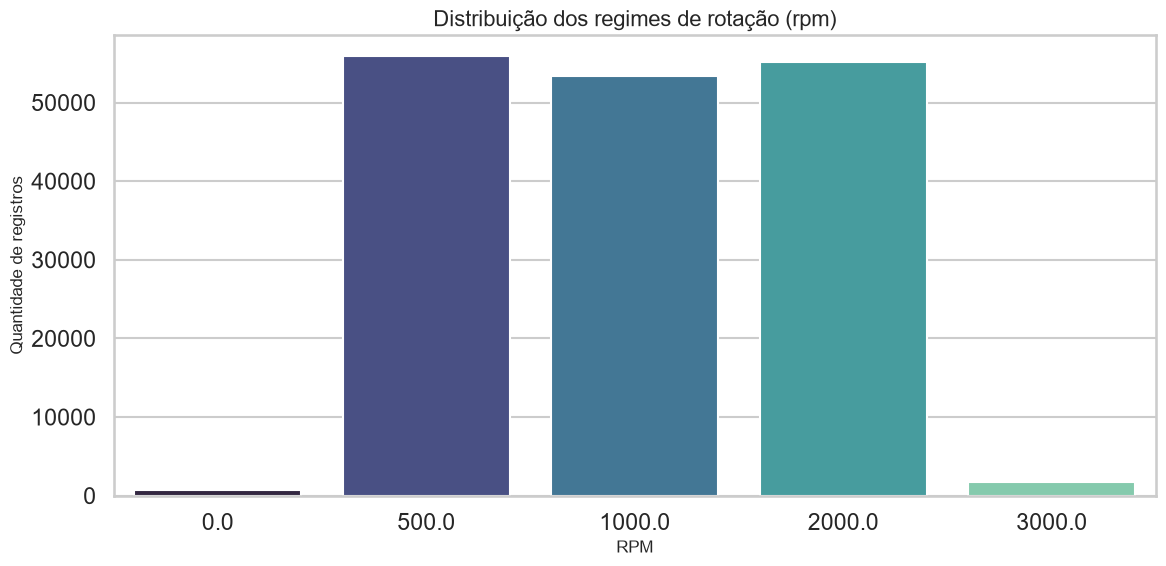

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(data=rpm_distribution, x='rpm', y='quantidade', palette='mako')
plt.title('Distribuição dos regimes de rotação (rpm)')
plt.xlabel('RPM')
plt.ylabel('Quantidade de registros')
plt.tight_layout()
plt.show()


A rotação é uma variável estruturante do problema. Qualquer modelo ou busca por similaridade deve respeitar o regime de `rpm`, sob risco de comparar assinaturas vibracionais de contextos incompatíveis.

## 4. Variáveis de sensores e separação entre classes

In [14]:
selected_features = [
    'temperature_c', 'z_rms_velocity_mm_s', 'x_rms_velocity_mm_s',
    'z_peak_acceleration_g', 'x_peak_acceleration_g',
    'z_rms_acceleration_g', 'x_rms_acceleration_g',
    'z_kurtosis', 'x_kurtosis', 'z_crest_factor', 'x_crest_factor', 'rpm'
]
feature_summary = df[selected_features].describe().T.round(3)
feature_summary


,count,mean,std,min,25%,50%,75%,max
temperature_c,166796.0,23.270,2.231,15.630,21.960,23.330,24.950,33.820
z_rms_velocity_mm_s,166796.0,1.728,0.712,0.312,1.443,1.600,1.834,37.095
x_rms_velocity_mm_s,166796.0,2.497,0.582,0.438,2.083,2.415,2.774,18.346
z_peak_acceleration_g,166796.0,0.583,0.786,0.021,0.449,0.500,0.579,38.409
x_peak_acceleration_g,166796.0,0.722,0.621,0.022,0.524,0.587,0.878,25.241
z_rms_acceleration_g,166796.0,0.121,0.107,0.015,0.078,0.096,0.131,3.635
x_rms_acceleration_g,166796.0,0.134,0.048,0.020,0.110,0.123,0.146,1.447
z_kurtosis,166796.0,2.651,1.003,2.031,2.398,2.498,2.763,65.535
x_kurtosis,166796.0,2.779,0.513,2.063,2.564,2.695,2.919,28.890
z_crest_factor,166796.0,3.720,0.549,2.378,3.408,3.634,3.921,23.705


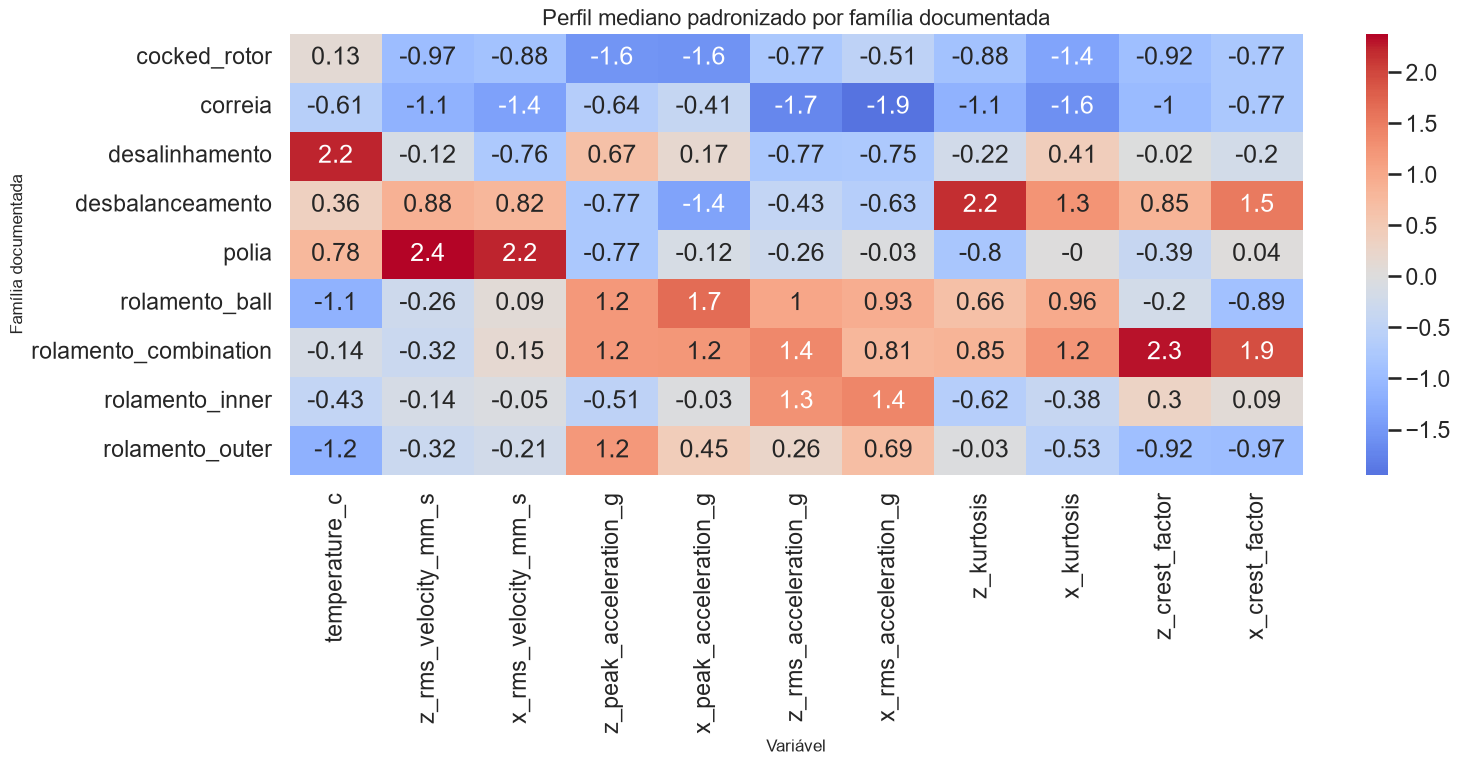

In [15]:
documented_only = df[df['documented']].copy()
top_documented = documented_only['canonical_fault'].value_counts().head(9).index
median_profile = documented_only[documented_only['canonical_fault'].isin(top_documented)].groupby('canonical_fault')[selected_features[:-1]].median()
scaled_profile = (median_profile - median_profile.mean()) / median_profile.std(ddof=0)

plt.figure(figsize=(16, 8))
sns.heatmap(scaled_profile.round(2), annot=True, cmap='coolwarm', center=0)
plt.title('Perfil mediano padronizado por família documentada')
plt.xlabel('Variável')
plt.ylabel('Família documentada')
plt.tight_layout()
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_10752\3702353481.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=boxplot_df, x='canonical_fault', y='x_rms_velocity_mm_s', palette='Set2')


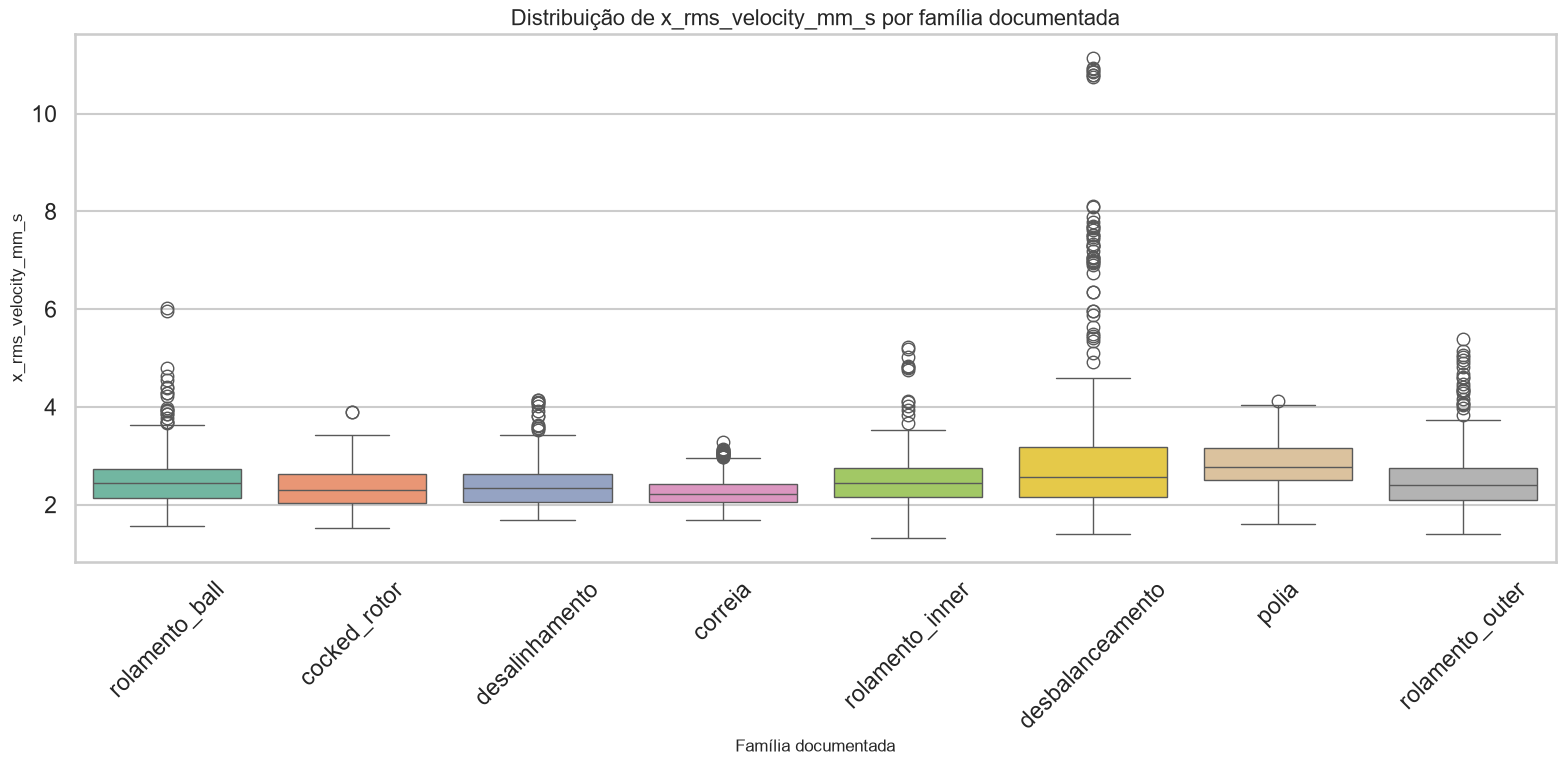

In [16]:
focus_faults = [
    'rolamento_inner', 'rolamento_outer', 'rolamento_ball',
    'desbalanceamento', 'desalinhamento', 'cocked_rotor',
    'polia', 'correia'
]
boxplot_df = documented_only[documented_only['canonical_fault'].isin(focus_faults)].sample(min(12000, len(documented_only)), random_state=42)

plt.figure(figsize=(16, 8))
sns.boxplot(data=boxplot_df, x='canonical_fault', y='x_rms_velocity_mm_s', palette='Set2')
plt.title('Distribuição de x_rms_velocity_mm_s por família documentada')
plt.xlabel('Família documentada')
plt.ylabel('x_rms_velocity_mm_s')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


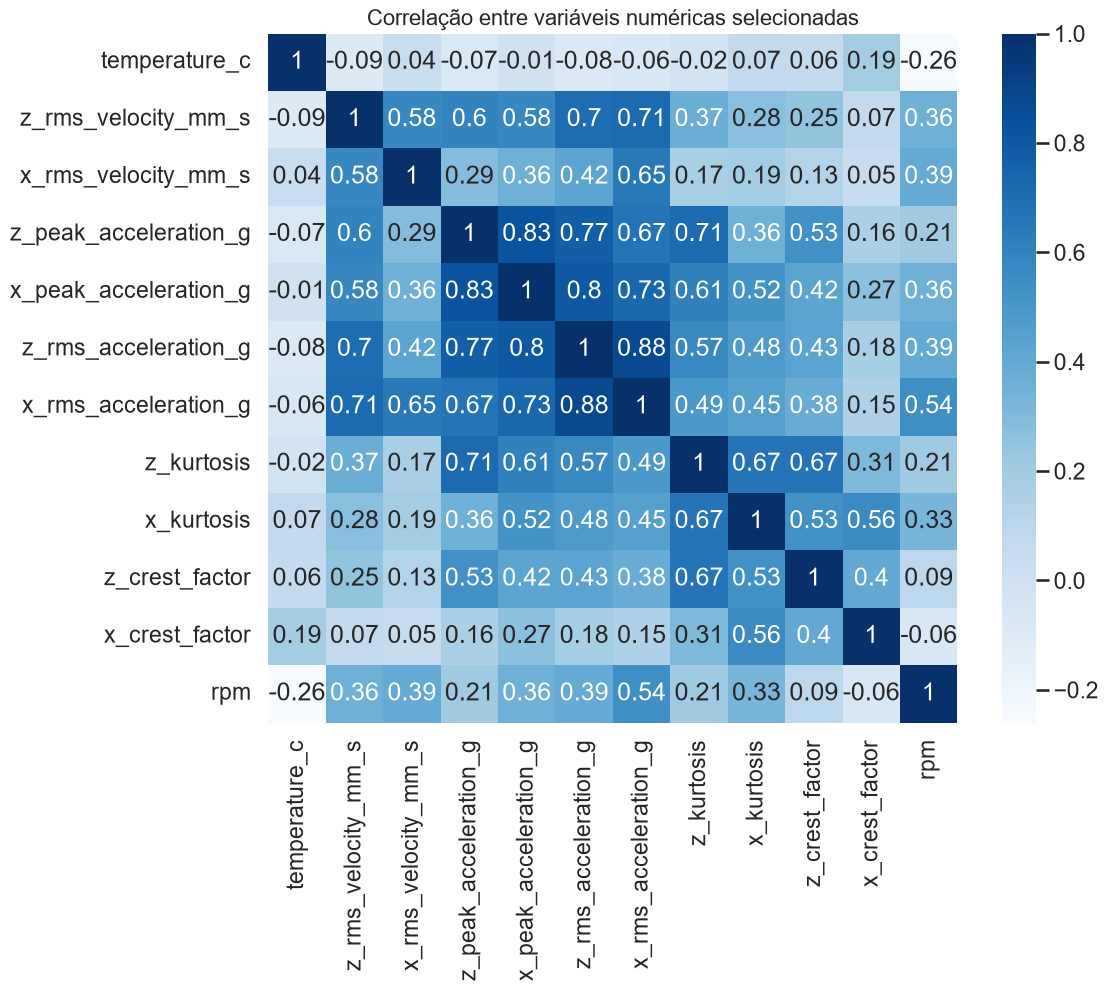

In [17]:
corr = df[selected_features].corr().round(2)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='Blues', square=True)
plt.title('Correlação entre variáveis numéricas selecionadas')
plt.tight_layout()
plt.show()


Os perfis medianos e os boxplots mostram que há sinal discriminativo nas variáveis vibracionais, mas parte das classes se aproxima em certos regimes. Isso reforça a necessidade de usar múltiplas variáveis e de condicionar a análise ao contexto operacional.

## 5. Análise orientada à prontidão prescritiva

In [18]:
prescriptive_readiness = pd.DataFrame({
    'criterio': [
        'Integridade estrutural do dataset',
        'Cobertura documental das famílias principais',
        'Padronização dos rótulos',
        'Suporte a busca por similaridade',
        'Pronto para prescrição sem governança adicional'
    ],
    'status': [
        'Atende',
        'Atende parcialmente',
        'Não atende',
        'Atende com preparo prévio',
        'Não atende'
    ],
    'comentario': [
        'Base sem faltantes e sem duplicidade de id.',
        'Há documentos para famílias centrais, mas nem todas as classes têm cobertura.',
        'A coluna fault mistura defeito, contexto e erros de digitação.',
        'As medições têm densidade suficiente para um baseline de similaridade.',
        'É preciso adicionar taxonomia, regras de recusa e mapeamento fault-documento.'
    ]
})
prescriptive_readiness


,criterio,status,comentario
0,Integridade estrutural do dataset,Atende,Base sem faltantes e sem duplicidade de id.
1,Cobertura documental das famílias principais,Atende parcialmente,"Há documentos para famílias centrais, mas nem ..."
2,Padronização dos rótulos,Não atende,"A coluna fault mistura defeito, contexto e err..."
3,Suporte a busca por similaridade,Atende com preparo prévio,As medições têm densidade suficiente para um b...
4,Pronto para prescrição sem governança adicional,Não atende,"É preciso adicionar taxonomia, regras de recus..."


## 6. Conclusões

- O dataset é forte como base histórica para diagnóstico por similaridade.
- O maior gargalo não é ausência de dados, mas sim governança semântica dos rótulos.
- A cobertura documental é suficiente para iniciar um protótipo prescritivo seguro em parte relevante da base.
- O próximo passo correto é padronizar `fault`, ligar famílias a documentos e só então partir para baseline de modelagem.
